<a href="https://colab.research.google.com/github/Elwing-Chou/ximen_ai_20260706/blob/main/ximen20260713.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


```
age age in years
sex
bmi body mass index
bp average blood pressure
s1 tc, total serum cholesterol
s2 ldl, low-density lipoproteins
s3 hdl, high-density lipoproteins
s4 tch, total cholesterol / HDL
s5 ltg, possibly log of serum triglycerides level
s6 glu, blood sugar level
```



In [2]:
# Step 1. 把你的資料整理成一個表格
# 哪個特徵重要: 不是你決定了, 是模型決定的
# 如果特徵有相關性呢? 你不用去掉某個, 模型決定哪個好, 用哪個
# 準備資料(x): 越多越好

import pandas as pd
from sklearn.datasets import load_diabetes

data = load_diabetes(scaled=False)

df = pd.DataFrame(data["data"],
                  columns=data["feature_names"])
df["target"] = data["target"]
df.to_csv("diabetes.csv", encoding="utf-8", index=False)
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,59.0,2.0,32.1,101.00,157.0,93.2,38.0,4.00,4.8598,87.0,151.0
1,48.0,1.0,21.6,87.00,183.0,103.2,70.0,3.00,3.8918,69.0,75.0
2,72.0,2.0,30.5,93.00,156.0,93.6,41.0,4.00,4.6728,85.0,141.0
3,24.0,1.0,25.3,84.00,198.0,131.4,40.0,5.00,4.8903,89.0,206.0
4,50.0,1.0,23.0,101.00,192.0,125.4,52.0,4.00,4.2905,80.0,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,60.0,2.0,28.2,112.00,185.0,113.8,42.0,4.00,4.9836,93.0,178.0
438,47.0,2.0,24.9,75.00,225.0,166.0,42.0,5.00,4.4427,102.0,104.0
439,60.0,2.0,24.9,99.67,162.0,106.6,43.0,3.77,4.1271,95.0,132.0
440,36.0,1.0,30.0,95.00,201.0,125.2,42.0,4.79,5.1299,85.0,220.0


In [3]:
# Step 2. 評估一下你的資料到底夠不夠
# 機器學習: 千筆以上
# 深度學習: 萬筆以上
# 問題複雜度: 複雜度(有效輸入越多個)越高, 越多資料

# Step 3. 分成兩部分
# 1. 訓練資料(給你的模型訓練)  2. 驗證資料(驗證模型用)
from sklearn.model_selection import train_test_split

x = df.drop("target", axis=1)
y = df["target"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)
y_train

,target
368,123.0
110,104.0
174,151.0
307,172.0
65,163.0
...,...
381,104.0
253,150.0
41,55.0
301,65.0


In [5]:
# Step 4. 建立模型
from sklearn.tree import DecisionTreeRegressor
# 過擬合: 任何模型都要防止, 防止過度學習訓練資料
# 因為過度學習訓練資料, 通常反而會在現實資料表現得很差
# 調參大部分時候就是為了控制這個擬合程度
reg = DecisionTreeRegressor(max_depth=2)
reg.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=2)

[Text(0.5, 0.8333333333333334, 's5 <= 4.6\nsquared_error = 5887.26\nsamples = 353\nvalue = 154.014'),
 Text(0.25, 0.5, 'bmi <= 26.95\nsquared_error = 3258.131\nsamples = 174\nvalue = 112.19'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'squared_error = 2318.037\nsamples = 134\nvalue = 99.194'),
 Text(0.375, 0.16666666666666666, 'squared_error = 3946.349\nsamples = 40\nvalue = 155.725'),
 Text(0.75, 0.5, 'bmi <= 28.05\nsquared_error = 5089.595\nsamples = 179\nvalue = 194.67'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'squared_error = 3910.42\nsamples = 97\nvalue = 164.948'),
 Text(0.875, 0.16666666666666666, 'squared_error = 4203.337\nsamples = 82\nvalue = 229.829')]

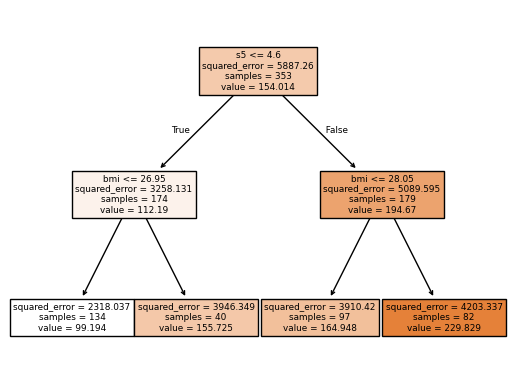

In [6]:
from sklearn.tree import plot_tree
plot_tree(reg,
          feature_names=x.columns,
          filled=True,
          max_depth=2)